In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
! pip install statsforecast
! pip install utilsforecast
from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *
import warnings
warnings.filterwarnings("ignore")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 3.9 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [ ]:
df = pd.read_csv('/content/preprocessed_power_data.csv')
df.drop(['LAT','LON'], axis=1, inplace=True)
df.rename(columns={'T2M' : 'temp'}, inplace=True)
df['DATE'] = pd.to_datetime(df['DATE'], format='%d-%m-%Y')
df.set_index('DATE', inplace=True)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3653 entries, 2016-01-01 to 2025-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   temp    3653 non-null   float64
dtypes: float64(1)
memory usage: 57.1 KB


,temp
DATE,
2016-01-01,16.25
2016-01-02,15.19
2016-01-03,15.40
2016-01-04,17.38
2016-01-05,20.21


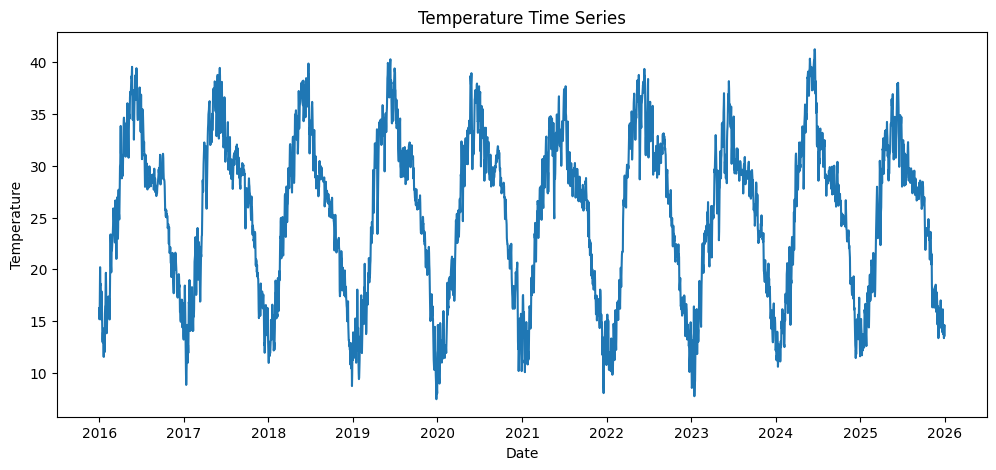

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df['temp'])
plt.title("Temperature Time Series")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()

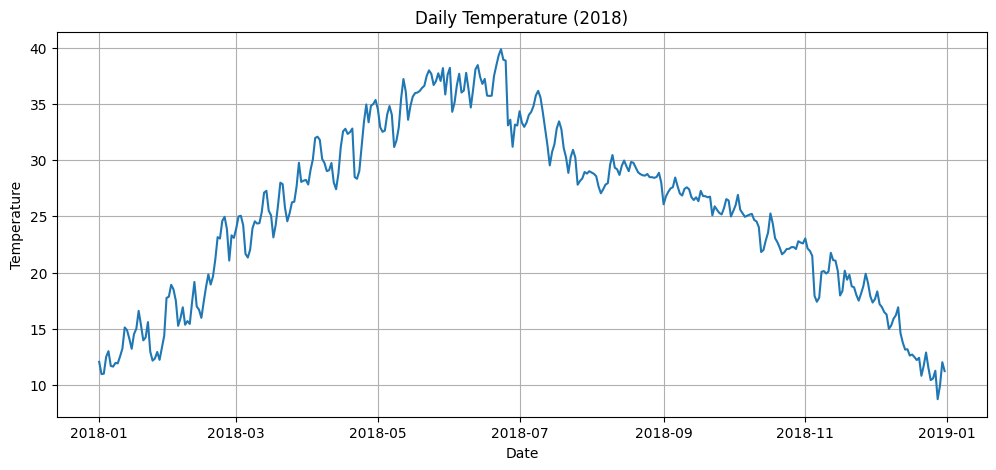

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(df.loc['2018'].index, df.loc['2018']['temp'])

plt.title("Daily Temperature (2018)")
plt.xlabel("Date")
plt.ylabel("Temperature")

plt.grid(True)
plt.show()

Decomposition

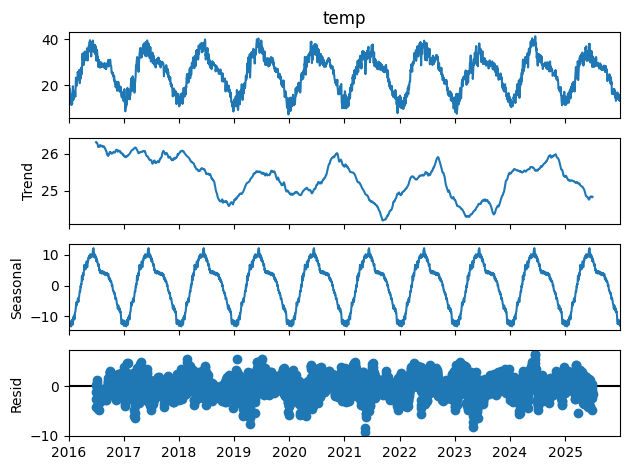

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['temp'], model='additive', period=365)

decomposition.plot()
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['temp'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -4.80811628805842
p-value: 5.247461435705291e-05


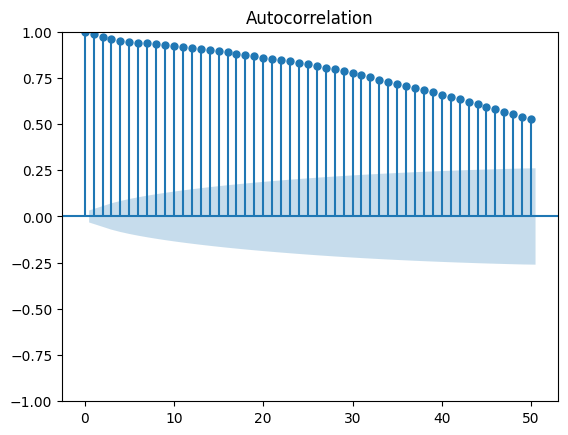

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df['temp'], lags=50)
plt.show()

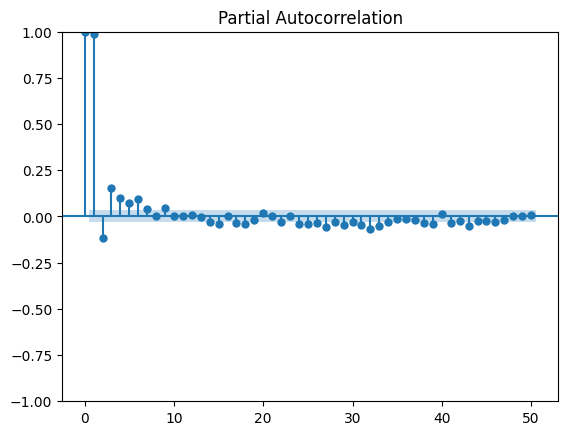

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df['temp'], lags=50)
plt.show()

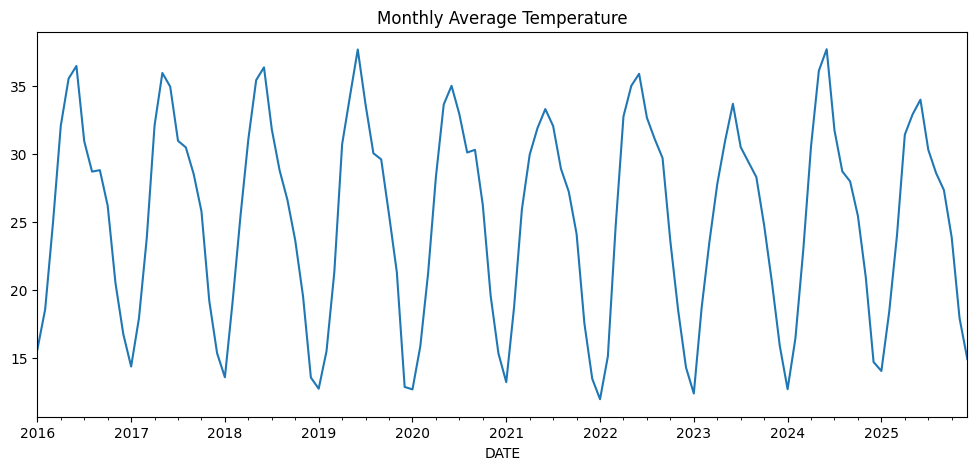

In [ ]:
df['temp'].resample('M').mean().plot(figsize=(12,5))
plt.title("Monthly Average Temperature")
plt.show()

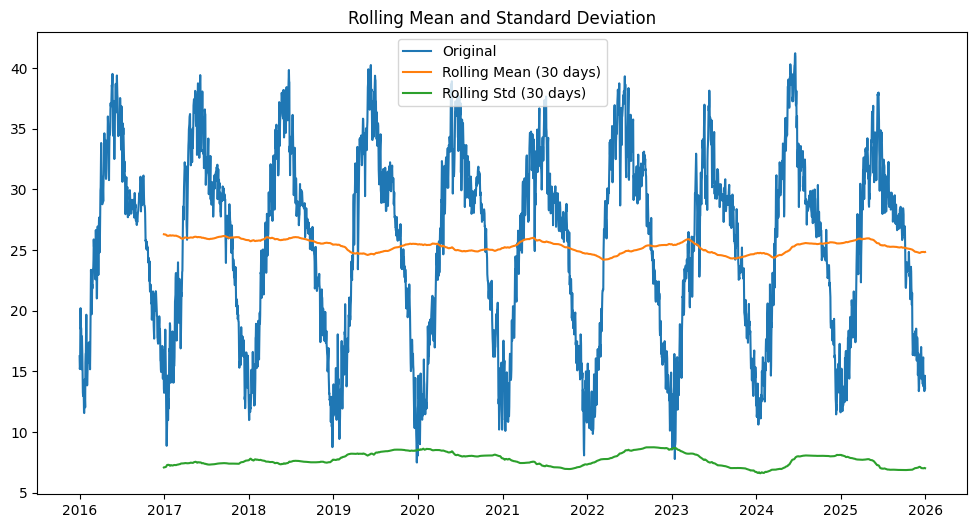

In [ ]:
rolling_mean = df['temp'].rolling(window=365).mean()
rolling_std = df['temp'].rolling(window=365).std()

plt.figure(figsize=(12,6))

plt.plot(df['temp'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean (30 days)')
plt.plot(rolling_std, label='Rolling Std (30 days)')

plt.legend()
plt.title("Rolling Mean and Standard Deviation")
plt.show()

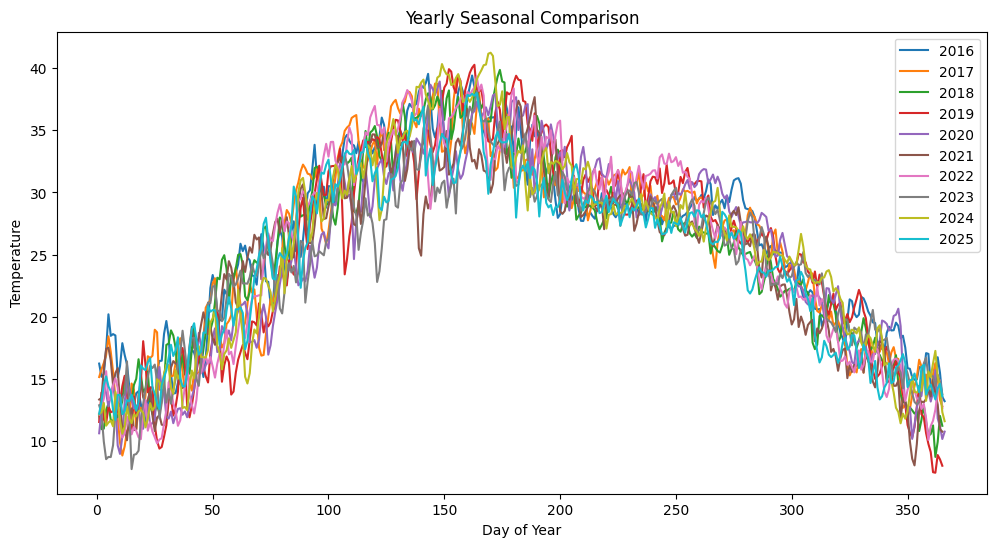

In [ ]:
df['year'] = df.index.year
df['day_of_year'] = df.index.dayofyear
plt.figure(figsize=(12,6))

for year in df['year'].unique():
    yearly_data = df[df['year'] == year]
    plt.plot(yearly_data['day_of_year'], yearly_data['temp'], label=str(year))

plt.xlabel("Day of Year")
plt.ylabel("Temperature")
plt.title("Yearly Seasonal Comparison")
plt.legend()
plt.show()

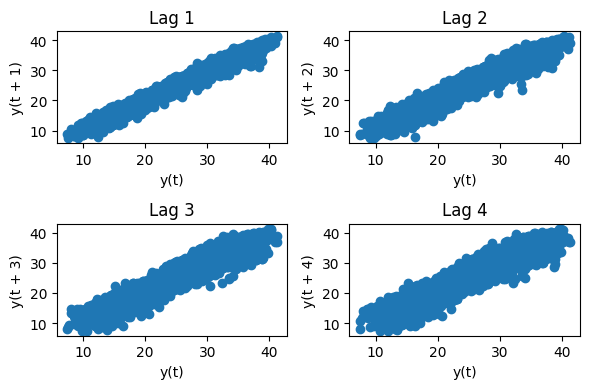

In [ ]:
from pandas.plotting import lag_plot

plt.figure(figsize=(6,4))

for i in range(1,5):
    plt.subplot(2,2,i)
    lag_plot(df['temp'], lag=i)
    plt.title(f"Lag {i}")

plt.tight_layout()
plt.show()

In [ ]:
train_size = int(len(df)*0.8)

train = df['temp'][:train_size]
test = df['temp'][train_size:]


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(1,0,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, forecast))

print("RMSE:", rmse)

RMSE: 7.218225653175705


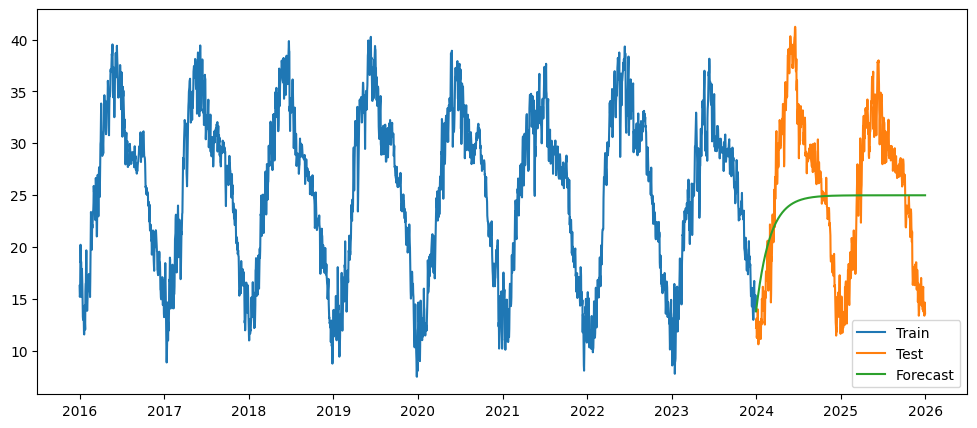

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, forecast, label="Forecast")

plt.legend()
plt.show()

In [ ]:
df_monthly = df['temp'].resample('M').mean()
train = df_monthly[:'2023']
test = df_monthly['2024':]

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

model_fit = model.fit()

In [ ]:
forecast = model_fit.forecast(steps=len(test))

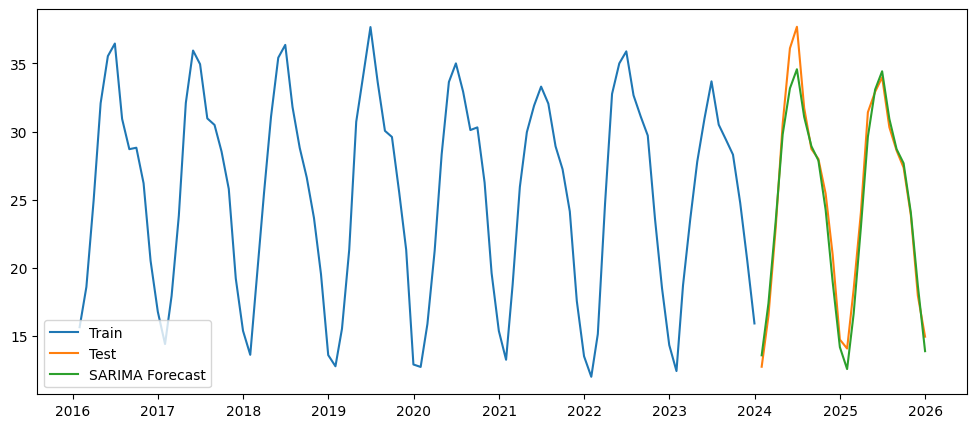

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, forecast, label='SARIMA Forecast')

plt.legend()
plt.show()

In [ ]:
rmse = np.sqrt(mean_squared_error(test, forecast))
print("SARIMA RMSE:", rmse)

SARIMA RMSE: 1.2807907527738407


# **Starting DL models implementation**

Normalizing the Temp data

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[['temp']])

In [ ]:
def create_sequences(data, window_size):

    X = []
    y = []

    for i in range(len(data) - window_size):

        X.append(data[i:i+window_size])
        y.append(data[i+window_size])

    return np.array(X), np.array(y)

In [ ]:
window_size = 30

X, y = create_sequences(scaled_data, window_size)

In [ ]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [ ]:
print(X_train.shape)
print(X_test.shape)

(2898, 30, 1)
(725, 30, 1)


In [ ]:
y_test_original = scaler.inverse_transform(y_test)

**LSTM**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

lstm_model = Sequential()

lstm_model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)))
lstm_model.add(Dropout(0.2))

lstm_model.add(LSTM(32))
lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - loss: 0.0672 - val_loss: 0.0040
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0086 - val_loss: 0.0037
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0079 - val_loss: 0.0033
Epoch 4/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0080 - val_loss: 0.0033
Epoch 5/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0073 - val_loss: 0.0034
Epoch 6/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.0068 - val_loss: 0.0030
Epoch 7/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0065 - val_loss: 0.0032
Epoch 8/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0063 - val_loss: 0.0030
Epoch 9/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0056 - val_loss: 0.0033
Epoch 10/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0055 - val_loss: 0.0029
Epoch 11/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0056 - val_loss: 0.0030
Epoch 12/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0

In [ ]:
y_pred_lstm = lstm_model.predict(X_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


In [ ]:
y_pred_lstm = scaler.inverse_transform(y_pred_lstm)
y_test_inv = scaler.inverse_transform(y_test)

Quantiative Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse_lstm = np.sqrt(mean_squared_error(y_test_inv, y_pred_lstm))
mae_lstm = mean_absolute_error(y_test_inv, y_pred_lstm)

mape_lstm = np.mean(np.abs((y_test_inv - y_pred_lstm) / y_test_inv)) * 100

r2_lstm = r2_score(y_test_inv, y_pred_lstm)

print("RMSE:", rmse_lstm)
print("MAE:", mae_lstm)
print("MAPE:", mape_lstm)
print("R2:", r2_lstm)

RMSE: 1.6077822682325202
MAE: 1.2444093399574017
MAPE: 5.423651945799474
R2: 0.9543636010202582


In [ ]:
import pandas as pd

results = pd.DataFrame(columns=["Model","RMSE","MAE","MAPE","R2"])

results.loc[len(results)] = [
    "LSTM",
    rmse_lstm,
    mae_lstm,
    mape_lstm,
    r2_lstm
]

print(results)

  Model      RMSE       MAE      MAPE        R2
0  LSTM  1.607782  1.244409  5.423652  0.954364


Graphical evaluation

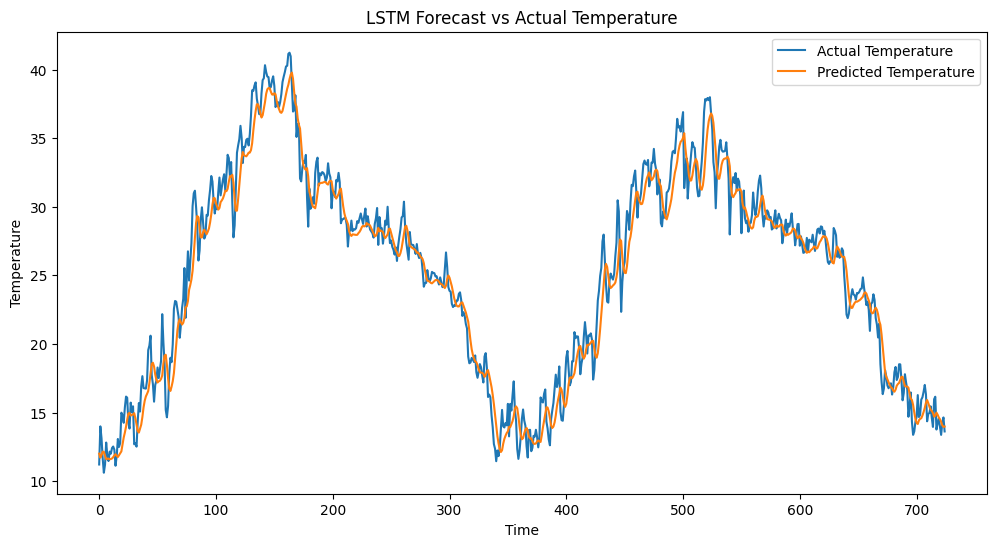

In [ ]:

plt.figure(figsize=(12,6))

plt.plot(y_test_inv, label='Actual Temperature')
plt.plot(y_pred_lstm, label='Predicted Temperature')

plt.title('LSTM Forecast vs Actual Temperature')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()

plt.show()

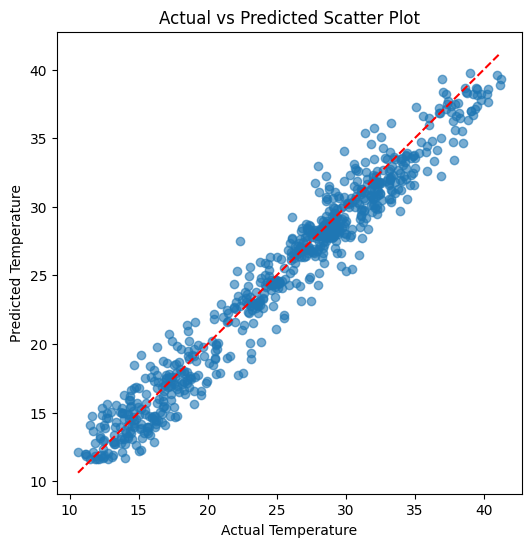

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_test_inv, y_pred_lstm, alpha=0.6)

plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Scatter Plot")

plt.plot(
    [y_test_inv.min(), y_test_inv.max()],
    [y_test_inv.min(), y_test_inv.max()],
    'r--'
)

plt.show()

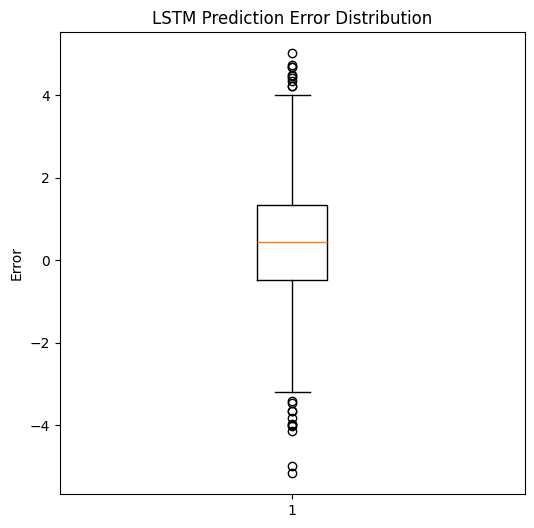

In [ ]:
errors_lstm = y_test_inv.flatten() - y_pred_lstm.flatten()
plt.figure(figsize=(6,6))

plt.boxplot(errors_lstm)

plt.title("LSTM Prediction Error Distribution")
plt.ylabel("Error")

plt.show()

In [ ]:
pip install skillmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.2/83.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 9.2 MB/s eta 0:00:00


**Bi**-**LSTM**

In [ ]:
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional

bilstm_model = Sequential()

bilstm_model.add(
    Bidirectional(
        LSTM(64, return_sequences=True),
        input_shape=(X_train.shape[1], 1)
    )
)

bilstm_model.add(Dropout(0.2))

bilstm_model.add(
    Bidirectional(
        LSTM(32)
    )
)

bilstm_model.add(Dropout(0.2))

bilstm_model.add(Dense(1))

bilstm_model.compile(
    optimizer='adam',
    loss='mse'
)

bilstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 30, 128)        │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,073 (293.25 KB)

 Trainable params: 75,073 (293.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_bilstm = bilstm_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 26s 162ms/step - loss: 0.0478 - val_loss: 0.0052
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - loss: 0.0073 - val_loss: 0.0034
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - loss: 0.0061 - val_loss: 0.0039
Epoch 4/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - loss: 0.0054 - val_loss: 0.0024
Epoch 5/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 0.0049 - val_loss: 0.0023
Epoch 6/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - loss: 0.0048 - val_loss: 0.0030
Epoch 7/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 0.0044 - val_loss: 0.0021
Epoch 8/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.0043 - val_loss: 0.0023
Epoch 9/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - loss: 0.0045 - val_loss: 0.0022
Epoch 10/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 0.0041 - val_loss: 0.0021
Epoch 11/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - loss: 0.0041 - val_loss: 0.0025
Epoch 12/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 

In [ ]:
y_pred_bilstm = bilstm_model.predict(X_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step


In [ ]:
y_pred_bilstm = scaler.inverse_transform(y_pred_bilstm)
y_test_inv = scaler.inverse_transform(y_test)

Quantiative evaluation

In [ ]:
import numpy as np

rmse_bilstm = np.sqrt(mean_squared_error(y_test_inv, y_pred_bilstm))

mae_bilstm = mean_absolute_error(y_test_inv, y_pred_bilstm)

mape_bilstm = np.mean(
    np.abs((y_test_inv - y_pred_bilstm) / y_test_inv)
) * 100

r2_bilstm = r2_score(y_test_inv, y_pred_bilstm)

print("RMSE:", rmse_bilstm)
print("MAE:", mae_bilstm)
print("MAPE:", mape_bilstm)
print("R2:", r2_bilstm)

RMSE: 1.3643631654084067
MAE: 1.0289344425069875
MAPE: 4.583266362773541
R2: 0.9671362687065691


In [ ]:
results.loc[len(results)] = [
    "BiLSTM",
    rmse_bilstm,
    mae_bilstm,
    mape_bilstm,
    r2_bilstm
]

print(results)

    Model       RMSE        MAE       MAPE        R2
0     CNN   1.438000   1.176000   4.919000  0.963000
1    LSTM   1.608000   1.244000   5.424000  0.954000
2     GNN  14.022000  11.965000  41.883000 -2.471000
3     GRU   1.157802   0.876223   3.918303  0.976334
4  BiLSTM   1.364363   1.028934   4.583266  0.967136


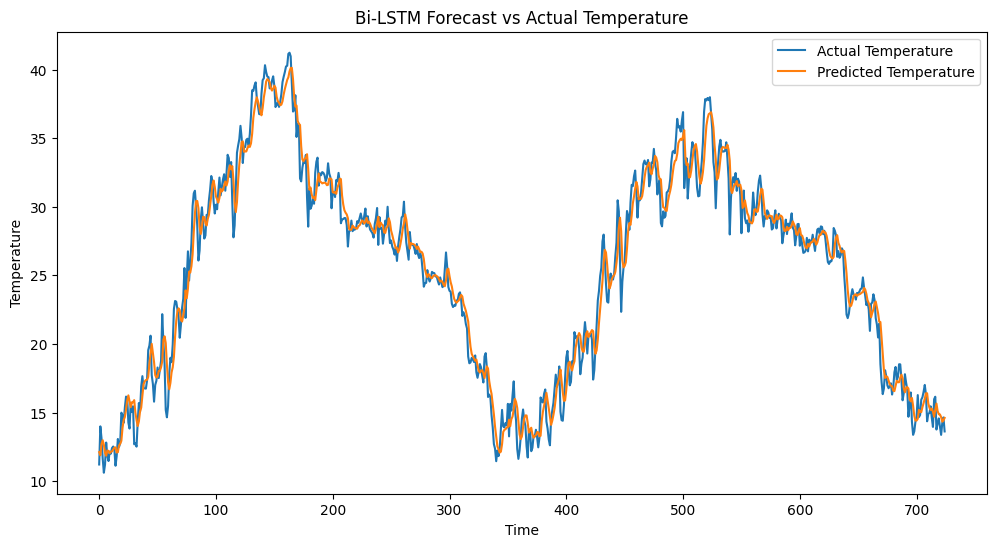

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(y_test_inv, label='Actual Temperature')
plt.plot(y_pred_bilstm, label='Predicted Temperature')

plt.title('Bi-LSTM Forecast vs Actual Temperature')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()

plt.show()

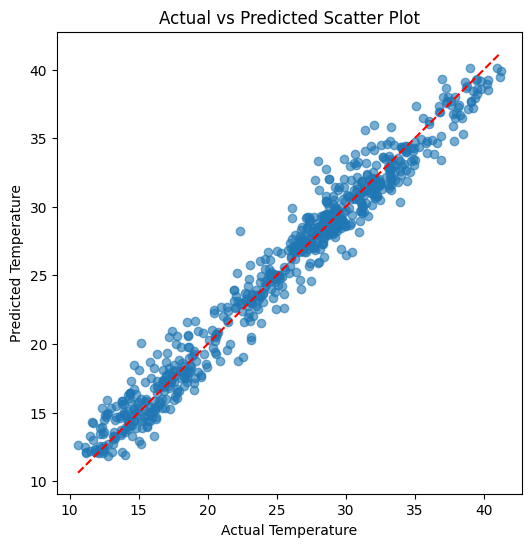

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_test_inv, y_pred_bilstm, alpha=0.6)

plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Scatter Plot")

plt.plot(
    [y_test_inv.min(), y_test_inv.max()],
    [y_test_inv.min(), y_test_inv.max()],
    'r--'
)

plt.show()

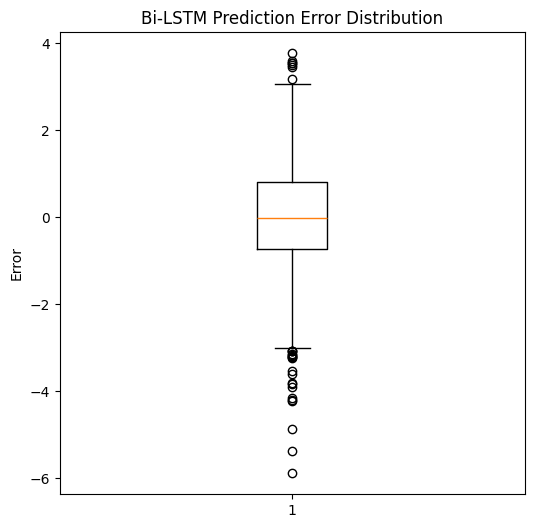

In [ ]:
errors_bilstm = y_test_inv.flatten() - y_pred_bilstm.flatten()
plt.figure(figsize=(6,6))

plt.boxplot(errors_bilstm)

plt.title("Bi-LSTM Prediction Error Distribution")
plt.ylabel("Error")

plt.show()

**GRU**

In [ ]:
from tensorflow.keras.layers import GRU
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

gru_model = Sequential()

gru_model.add(
    GRU(64, return_sequences=True, input_shape=(X_train.shape[1], 1))
)

gru_model.add(Dropout(0.2))

gru_model.add(
    GRU(32)
)

gru_model.add(Dropout(0.2))

gru_model.add(Dense(1))

gru_model.compile(
    optimizer='adam',
    loss='mse'
)

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,305 (87.13 KB)

 Trainable params: 22,305 (87.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 23s 153ms/step - loss: 0.0708 - val_loss: 0.0024
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - loss: 0.0074 - val_loss: 0.0032
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.0065 - val_loss: 0.0021
Epoch 4/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - loss: 0.0060 - val_loss: 0.0027
Epoch 5/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.0058 - val_loss: 0.0022
Epoch 6/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 0.0058 - val_loss: 0.0019
Epoch 7/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0052 - val_loss: 0.0018
Epoch 8/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 0.0048 - val_loss: 0.0018
Epoch 9/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - loss: 0.0045 - val_loss: 0.0017
Epoch 10/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0043 - val_loss: 0.0017
Epoch 11/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0044 - val_loss: 0.0015
Epoch 12/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - loss:

In [ ]:
y_pred_gru = gru_model.predict(X_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


Quantiative evaluation

In [ ]:
y_pred_gru = scaler.inverse_transform(y_pred_gru)
y_test_inv = scaler.inverse_transform(y_test)

In [ ]:
rmse_gru = np.sqrt(mean_squared_error(y_test_inv, y_pred_gru))

mae_gru = mean_absolute_error(y_test_inv, y_pred_gru)

mape_gru = np.mean(
    np.abs((y_test_inv - y_pred_gru) / y_test_inv)
) * 100

r2_gru = r2_score(y_test_inv, y_pred_gru)

print("RMSE:", rmse_gru)
print("MAE:", mae_gru)
print("MAPE:", mape_gru)
print("R2:", r2_gru)

RMSE: 1.157802336751475
MAE: 0.8762225220778892
MAPE: 3.91830349208035
R2: 0.9763339519171526


In [ ]:
results.loc[len(results)] = [
    "GRU",
    rmse_gru,
    mae_gru,
    mape_gru,
    r2_gru
]

print(results)

  Model       RMSE        MAE       MAPE        R2
0   CNN   1.438000   1.176000   4.919000  0.963000
1  LSTM   1.608000   1.244000   5.424000  0.954000
2   GNN  14.022000  11.965000  41.883000 -2.471000
3   GRU   1.157802   0.876223   3.918303  0.976334


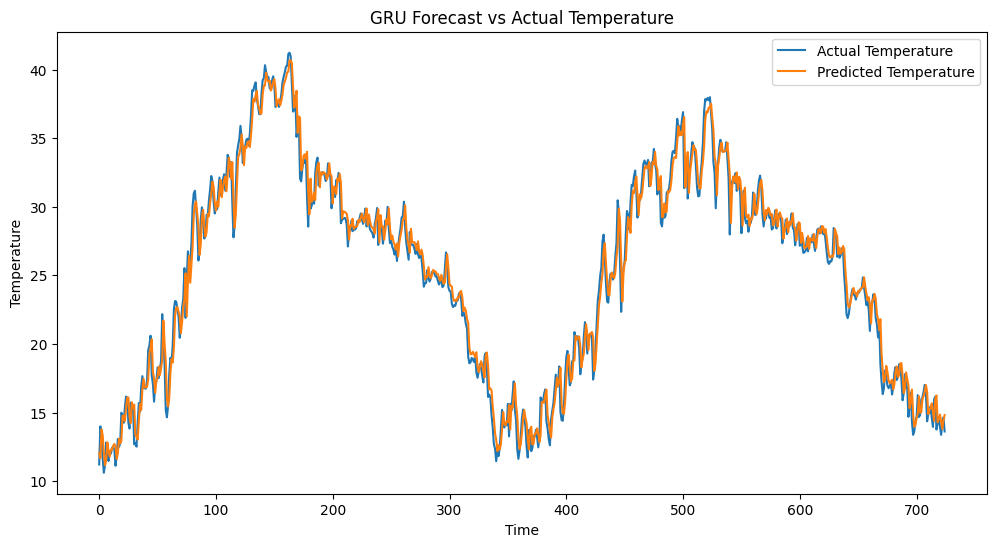

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(y_test_inv, label='Actual Temperature')
plt.plot(y_pred_gru, label='Predicted Temperature')

plt.title('GRU Forecast vs Actual Temperature')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()

plt.show()

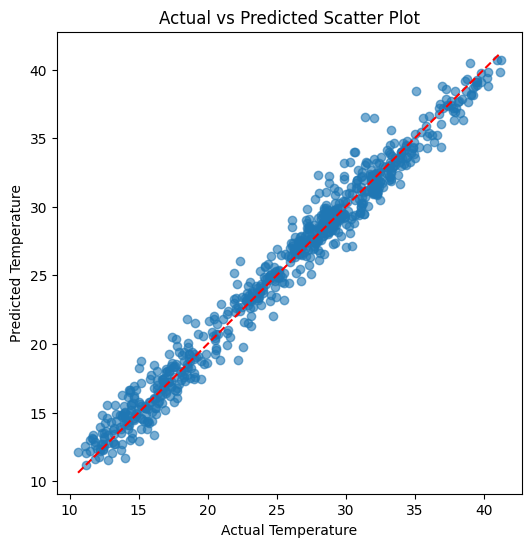

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_test_inv, y_pred_gru, alpha=0.6)

plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Scatter Plot")

plt.plot(
    [y_test_inv.min(), y_test_inv.max()],
    [y_test_inv.min(), y_test_inv.max()],
    'r--'
)

plt.show()

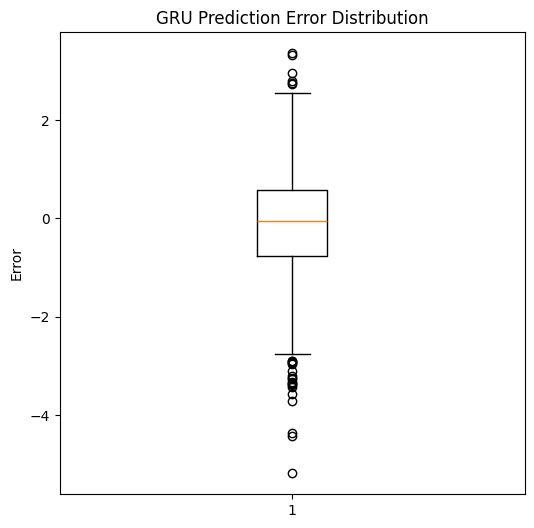

In [ ]:
errors_gru = y_test_inv.flatten() - y_pred_gru.flatten()
plt.figure(figsize=(6,6))

plt.boxplot(errors_gru)

plt.title("GRU Prediction Error Distribution")
plt.ylabel("Error")

plt.show()

**CNN**

In [ ]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

cnn_model = Sequential()

cnn_model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        input_shape=(X_train.shape[1],1)
    )
)

cnn_model.add(MaxPooling1D(pool_size=2))

cnn_model.add(
    Conv1D(
        filters=32,
        kernel_size=3,
        activation='relu'
    )
)

cnn_model.add(Flatten())

cnn_model.add(Dense(50, activation='relu'))

cnn_model.add(Dropout(0.2))

cnn_model.add(Dense(1))

cnn_model.compile(
    optimizer='adam',
    loss='mse'
)

cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 28, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 12, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │        19,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,733 (100.52 KB)

 Trainable params: 25,733 (100.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_cnn = cnn_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0795 - val_loss: 0.0059
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0116 - val_loss: 0.0039
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0085 - val_loss: 0.0025
Epoch 4/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0079 - val_loss: 0.0025
Epoch 5/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0073 - val_loss: 0.0021
Epoch 6/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0062 - val_loss: 0.0017
Epoch 7/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0063 - val_loss: 0.0026
Epoch 8/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0062 - val_loss: 0.0016
Epoch 9/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0055 - val_loss: 0.0028
Epoch 10/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0057 - val_loss: 0.0016
Epoch 11/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0060 - val_loss: 0.0015
Epoch 12/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0052 - val_lo

In [ ]:
y_pred_cnn = cnn_model.predict(X_test)
y_pred_cnn = scaler.inverse_transform(y_pred_cnn)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [ ]:
rmse_cnn = np.sqrt(mean_squared_error(y_test_inv, y_pred_cnn))

mae_cnn = mean_absolute_error(y_test_inv, y_pred_cnn)

mape_cnn = np.mean(
    np.abs((y_test_inv - y_pred_cnn) / y_test_inv)
) * 100

r2_cnn = r2_score(y_test_inv, y_pred_cnn)

print("RMSE:", rmse_cnn)
print("MAE:", mae_cnn)
print("MAPE:", mape_cnn)
print("R2:", r2_cnn)

RMSE: 1.438329956426764
MAE: 1.1758132073764143
MAPE: 4.918891100770879
R2: 0.9634763686633392


In [ ]:
results.loc[len(results)] = [
    "CNN",
    rmse_cnn,
    mae_cnn,
    mape_cnn,
    r2_cnn
]

print(results)

  Model      RMSE       MAE      MAPE        R2
0  LSTM  1.607782  1.244409  5.423652  0.954364
1   CNN  1.438330  1.175813  4.918891  0.963476


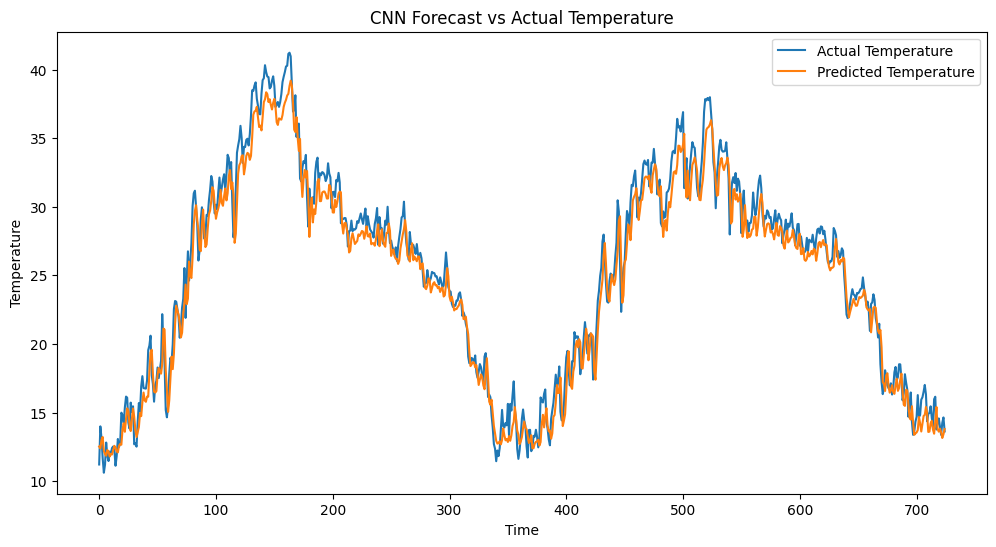

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(y_test_inv, label='Actual Temperature')
plt.plot(y_pred_cnn, label='Predicted Temperature')

plt.title('CNN Forecast vs Actual Temperature')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()

plt.show()

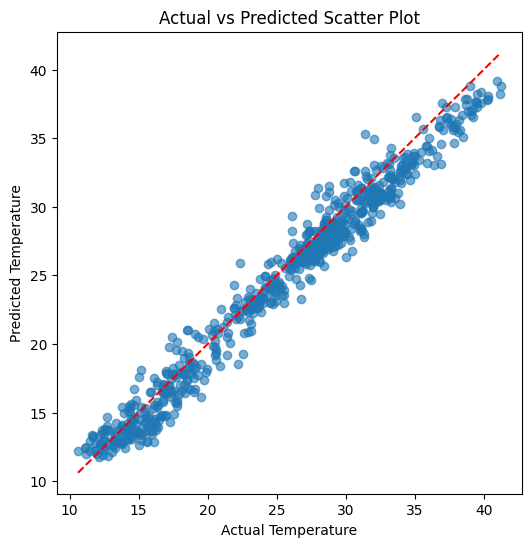

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_test_inv, y_pred_cnn, alpha=0.6)

plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Scatter Plot")

plt.plot(
    [y_test_inv.min(), y_test_inv.max()],
    [y_test_inv.min(), y_test_inv.max()],
    'r--'
)

plt.show()

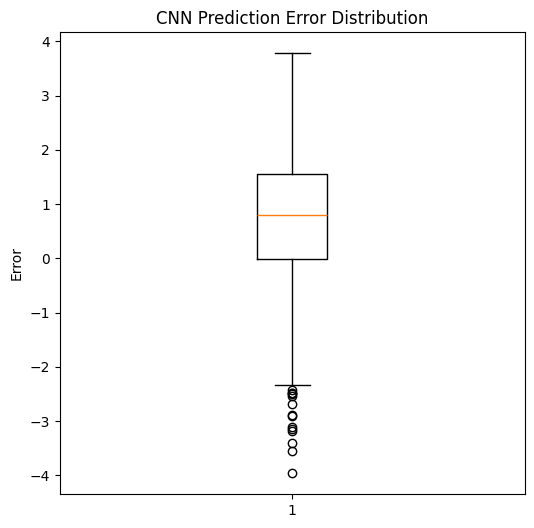

In [ ]:
errors_gru = y_test_inv.flatten() - y_pred_cnn.flatten()
plt.figure(figsize=(6,6))

plt.boxplot(errors_gru)

plt.title("CNN Prediction Error Distribution")
plt.ylabel("Error")

plt.show()

**GNN**

In [ ]:
pip install torch torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.9 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

In [ ]:
num_nodes = X_train.shape[1]

edge_index = []

for i in range(num_nodes-1):

    edge_index.append([i, i+1])
    edge_index.append([i+1, i])

edge_index = torch.tensor(edge_index).t().contiguous()

In [ ]:
X_train_torch = torch.tensor(X_train, dtype=torch.float)
y_train_torch = torch.tensor(y_train, dtype=torch.float)

X_test_torch = torch.tensor(X_test, dtype=torch.float)
y_test_torch = torch.tensor(y_test, dtype=torch.float)

In [ ]:
import torch.nn as nn

class GNNModel(nn.Module):

    def __init__(self):

        super(GNNModel, self).__init__()

        self.conv1 = GCNConv(1, 32)
        self.conv2 = GCNConv(32, 16)

        self.fc = nn.Linear(16,1)

    def forward(self, x, edge_index):

        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))

        x = x.mean(dim=0)

        x = self.fc(x)

        return x

In [ ]:
model_gnn = GNNModel()

optimizer = torch.optim.Adam(model_gnn.parameters(), lr=0.01)

criterion = nn.MSELoss()

In [ ]:
epochs = 20

for epoch in range(epochs):

    total_loss = 0

    for i in range(len(X_train_torch)):

        optimizer.zero_grad()

        x = X_train_torch[i]

        y = y_train_torch[i]

        pred = model_gnn(x, edge_index)

        loss = criterion(pred, y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print("Epoch:", epoch, "Loss:", total_loss)

Epoch: 0 Loss: 13.566188514936023
Epoch: 1 Loss: 13.772938412411303
Epoch: 2 Loss: 13.775549419703182
Epoch: 3 Loss: 13.775818844633445
Epoch: 4 Loss: 13.775845922312858
Epoch: 5 Loss: 13.775846836516866
Epoch: 6 Loss: 13.775846755277609
Epoch: 7 Loss: 13.775846755277609
Epoch: 8 Loss: 13.775846755277609
Epoch: 9 Loss: 13.775846755277609
Epoch: 10 Loss: 13.775846755277609
Epoch: 11 Loss: 13.775846755277609
Epoch: 12 Loss: 13.775846755277609
Epoch: 13 Loss: 13.775846755277609
Epoch: 14 Loss: 13.775846755277609
Epoch: 15 Loss: 13.775846755277609
Epoch: 16 Loss: 13.775846755277609
Epoch: 17 Loss: 13.775846755277609
Epoch: 18 Loss: 13.775846755277609
Epoch: 19 Loss: 13.775846755277609
Epoch: 20 Loss: 13.775846755277609
Epoch: 21 Loss: 13.775846755277609
Epoch: 22 Loss: 13.775846755277609
Epoch: 23 Loss: 13.775846755277609
Epoch: 24 Loss: 13.775846755277609
Epoch: 25 Loss: 13.775846755277609
Epoch: 26 Loss: 13.775846755277609
Epoch: 27 Loss: 13.775846755277609
Epoch: 28 Loss: 13.77584675527

In [ ]:
predictions = []

with torch.no_grad():

    for i in range(len(X_test_torch)):

        pred = model_gnn(X_test_torch[i], edge_index)

        predictions.append(pred.item())

y_pred_gnn = np.array(predictions).reshape(-1,1)

Quantiative evaluation

In [ ]:
y_pred_gnn = scaler.inverse_transform(y_pred_gnn)

In [ ]:
rmse_gnn = np.sqrt(mean_squared_error(y_test_inv, y_pred_gnn))

mae_gnn = mean_absolute_error(y_test_inv, y_pred_gnn)

mape_gnn = np.mean(
    np.abs((y_test_inv - y_pred_gnn) / y_test_inv)
) * 100

r2_gnn = r2_score(y_test_inv, y_pred_gnn)

print("RMSE:", rmse_gnn)
print("R2:", r2_gnn)

RMSE: 14.021828600381523
R2: -2.471092660081575


In [ ]:
results.loc[len(results)] = [
    "GNN",
    rmse_gnn,
    mae_gnn,
    mape_gnn,
    r2_gnn
]

print(results)

  Model       RMSE        MAE       MAPE        R2
0  LSTM   1.607782   1.244409   5.423652  0.954364
1   CNN   1.438330   1.175813   4.918891  0.963476
2   GNN  14.021829  11.964985  41.882602 -2.471093


Graph Neural Networks exhibited poor forecasting performance due to the absence of spatial dependencies in the dataset. The model is better suited for spatio-temporal forecasting problems involving multiple interconnected nodes.

In [ ]:
results = results.drop_duplicates()
results = results.reset_index(drop=True)
results = results.sort_values(by="RMSE")
results = results.reset_index(drop=True)
results = results.round(3)
results

,Model,RMSE,MAE,MAPE,R2
0,GRU,1.158,0.876,3.918,0.976
1,BiLSTM,1.364,1.029,4.583,0.967
2,CNN,1.438,1.176,4.919,0.963
3,LSTM,1.608,1.244,5.424,0.954
4,GNN,14.022,11.965,41.883,-2.471


**Statistical Analysis**

In [ ]:
from scipy.stats import friedmanchisquare

rmse = [1.158, 1.364, 1.438, 1.608, 14.022]
mae  = [0.876, 1.029, 1.176, 1.244, 11.965]
mape = [3.918, 4.583, 4.919, 5.424, 41.883]

stat, p = friedmanchisquare(rmse, mae, mape)

print("Friedman Statistic:", stat)
print("p-value:", p)

Friedman Statistic: 10.0
p-value: 0.006737946999085468


Result of friedmanchisquare = Models are significantly different

In [ ]:
!pip install dieboldmariano

In [ ]:
from dieboldmariano import dm_test

actual = y_test_inv.flatten()

pred_gru = y_pred_gru.flatten()
pred_bilstm = y_pred_bilstm.flatten()
pred_cnn = y_pred_cnn.flatten()
pred_lstm = y_pred_lstm.flatten()
pred_gnn = y_pred_gnn.flatten()

In [ ]:
loss = lambda u, v: (u - v) ** 2

In [ ]:
dm_stat, p_value = dm_test(actual, pred_gru, pred_bilstm, h=1, loss=loss)

print("GRU vs BiLSTM")
print("DM Statistic:", dm_stat)
print("p-value:", p_value)

GRU vs BiLSTM
DM Statistic: -7.1506424094704295
p-value: 2.116427591692155e-12


In [ ]:
dm_stat, p_value = dm_test(actual, pred_gru, pred_cnn, h=1, loss=loss)

print("GRU vs CNN")
print("DM Statistic:", dm_stat)
print("p-value:", p_value)

GRU vs CNN
DM Statistic: -8.212866608751291
p-value: 9.914348022581368e-16


In [ ]:
dm_stat, p_value = dm_test(actual, pred_gru, pred_lstm, h=1, loss=loss)

print("GRU vs LSTM")
print("DM Statistic:", dm_stat)
print("p-value:", p_value)

GRU vs LSTM
DM Statistic: -10.420622278775001
p-value: 8.704239753906599e-24


In [ ]:
dm_stat, p_value = dm_test(actual, pred_gru, pred_gnn, h=1, loss=loss)

print("GRU vs GNN")
print("DM Statistic:", dm_stat)
print("p-value:", p_value)

GRU vs GNN
DM Statistic: -29.31251307818559
p-value: 3.9374812714363374e-125


In [ ]:
def calculate_aic_bic(actual, predicted, num_params):

    actual = actual.flatten()
    predicted = predicted.flatten()

    residuals = actual - predicted
    rss = np.sum(residuals**2)

    n = len(actual)
    k = num_params

    aic = n * np.log(rss/n) + 2*k
    bic = n * np.log(rss/n) + k * np.log(n)

    return aic, bic

In [ ]:
aic_gru, bic_gru = calculate_aic_bic(
    y_test_inv,
    y_pred_gru,
    gru_model.count_params()
)

In [ ]:
aic_bilstm, bic_bilstm = calculate_aic_bic(
    y_test_inv,
    y_pred_bilstm,
    bilstm_model.count_params()
)

In [ ]:
aic_cnn, bic_cnn = calculate_aic_bic(
    y_test_inv,
    y_pred_cnn,
    cnn_model.count_params()
)

In [ ]:
aic_lstm, bic_lstm = calculate_aic_bic(
    y_test_inv,
    y_pred_lstm,
    lstm_model.count_params()
)

In [ ]:
gnn_params = sum(p.numel() for p in model_gnn.parameters())
aic_gnn, bic_gnn = calculate_aic_bic(
    y_test_inv,
    y_pred_gnn,
    gnn_params
)

In [ ]:
results["AIC"] = [
    aic_gru,
    aic_bilstm,
    aic_cnn,
    aic_lstm,
    aic_gnn
]

results["BIC"] = [
    bic_gru,
    bic_bilstm,
    bic_cnn,
    bic_lstm,
    bic_gnn
]

print(results)

    Model    RMSE     MAE    MAPE     R2            AIC            BIC
0     GRU   1.158   0.876   3.918  0.976   44822.459323  147117.018084
1  BiLSTM   1.364   1.029   4.583  0.967  150596.497273  494894.161918
2     CNN   1.438   1.176   4.919  0.963   51993.049898  170009.005092
3    LSTM   1.608   1.244   5.424  0.954   59378.540847  193959.748058
4     GNN  14.022  11.965  41.883 -2.471    5046.892187    7839.870724


**Combined Taylor Diagram**

In [ ]:
pip install skillmetrics

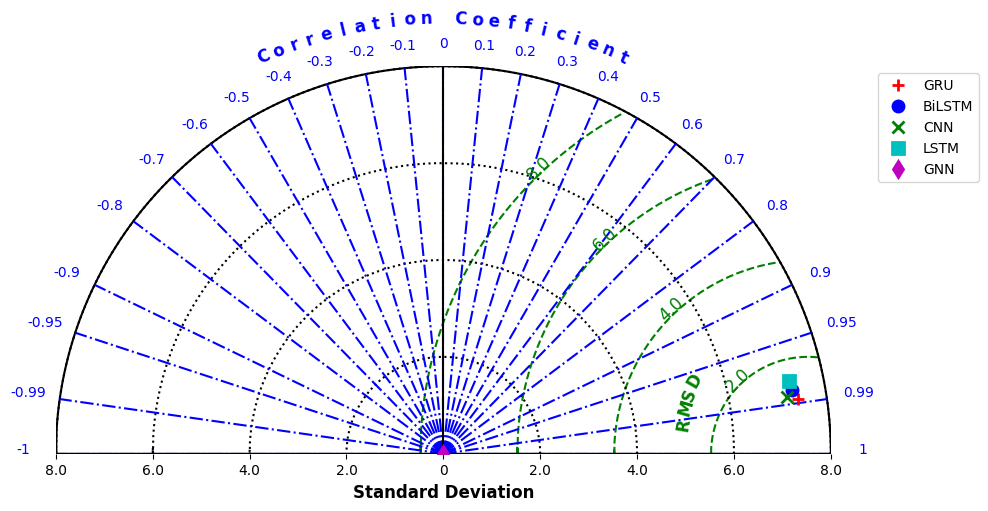

In [ ]:
import skill_metrics as sm

ref = y_test_inv.flatten()

# Reference standard deviation
std_ref = np.std(ref)

# Model standard deviations
std_models = [
    np.std(y_pred_gru),
    np.std(y_pred_bilstm),
    np.std(y_pred_cnn),
    np.std(y_pred_lstm),
    np.std(y_pred_gnn)
]

# Correlations
corr_models = [
    np.corrcoef(ref, y_pred_gru.flatten())[0,1],
    np.corrcoef(ref, y_pred_bilstm.flatten())[0,1],
    np.corrcoef(ref, y_pred_cnn.flatten())[0,1],
    np.corrcoef(ref, y_pred_lstm.flatten())[0,1],
    np.corrcoef(ref, y_pred_gnn.flatten())[0,1]
]

# RMSE
rmse_models = [
    np.sqrt(np.mean((ref - y_pred_gru.flatten())**2)),
    np.sqrt(np.mean((ref - y_pred_bilstm.flatten())**2)),
    np.sqrt(np.mean((ref - y_pred_cnn.flatten())**2)),
    np.sqrt(np.mean((ref - y_pred_lstm.flatten())**2)),
    np.sqrt(np.mean((ref - y_pred_gnn.flatten())**2))
]

# Combine reference + models
std_all = np.array([std_ref] + std_models)
rmse_all = np.array([0] + rmse_models)
corr_all = np.array([1] + corr_models)

labels = [
    "Reference",
    "GRU",
    "BiLSTM",
    "CNN",
    "LSTM",
    "GNN"
]

# Marker styles
markers = ['o','s','^','D','P','X']
colors = ['black','red','green','blue','purple','orange']

plt.figure(figsize=(10,8))

sm.taylor_diagram(
    std_all,
    rmse_all,
    corr_all,
    markerLabel=labels,
    markerSize=8,
    markerLegend='on',
    colCOR='blue',
    colRMS='green',
    colSTD='black'
)


plt.show()